# Market Risk Modelling and Backtesting in Python

## Research Question

How do historical and parametric risk estimates differ, and how sensitive are they to the confidence level and estimation window?


In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
print('Market risk project is ready')

Market risk project is ready


In [4]:
print('Pandas version:', pd.__version__)
print('NumPy version:', np.__version__)

Pandas version: 2.0.3
NumPy version: 1.24.3


In [5]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [6]:
import yfinance as yf
tickers = ['SPY', 'VGK','GLD'] #This creates a list containing the symbols of three exchange-traded funds
data = yf.download(tickers,start="2021-01-01",end="2026-09-01",auto_adjust=True) #This downloads the historical price data for the specified tickers and date range, and selects the 'Close' column
data.head() #This displays the first few rows of the data DataFrame

#Download adjusted daily market data for US equities, #
#European equities and gold from January 2021 until the end of August 2026, 
#save it as data, and display its first five observations.

[*********************100%***********************]  3 of 3 completed


Price            Close                               High              \
Ticker             GLD         SPY        VGK         GLD         SPY   
Date                                                                    
2021-01-04  182.330002  342.436951  50.913780  182.399994  348.621043   
2021-01-05  182.869995  344.795441  51.372684  183.210007  345.881847   
2021-01-06  179.899994  346.856812  51.981781  181.580002  350.041732   
2021-01-07  179.479996  352.010193  52.140320  179.919998  352.753015   
2021-01-08  173.339996  354.015869  52.382275  176.990005  354.229416   

Price                         Low                               Open  \
Ticker            VGK         GLD         SPY        VGK         GLD   
Date                                                                   
2021-01-04  51.681407  180.960007  338.750638  50.621746  181.970001   
2021-01-05  51.489497  181.820007  341.749824  50.930465  182.869995   
2021-01-06  52.290500  178.240005  342.743378  51.589625  181.490005   
2021-01-07  52.198726  178.839996  349.048142  51.948410  179.690002   
2021-01-08  52.423996  171.479996  350.153132  51.864961  176.830002   

Price                                Volume                      
Ticker             SPY        VGK       GLD        SPY      VGK  
Date                                                             
2021-01-04  348.491033  51.597970  14331400  110210800  4267900  
2021-01-05  341.796269  50.972183  12718800   66426200  2866100  
2021-01-06  343.291214  51.656374  18453500  107997700  4947200  
2021-01-07  349.224568  52.031850   7110200   68766800  2262400  
2021-01-08  353.393734  52.365587  24399900   71677200  5066200

In [7]:
 prices = data['Close'].copy() #This creates a new DataFrame called prices that contains only the 'Close' column of the data DataFrame
 prices.columns.name = None #This removes the name of the columns in the prices DataFrame
 prices.head() #This displays the fi#rst few rows of the prices DataFrame

,GLD,SPY,VGK
Date,,,
2021-01-04,182.330002,342.436951,50.913780
2021-01-05,182.869995,344.795441,51.372684
2021-01-06,179.899994,346.856812,51.981781
2021-01-07,179.479996,352.010193,52.140320
2021-01-08,173.339996,354.015869,52.382275


In [8]:
prices = prices.dropna()
prices.to_csv('../data/prices.csv') #This saves the prices DataFrame to a CSV file named 'market_data.csv' in the 'data' directory
print('Market data saved to market_data.csv') #This prints a message indicating that the market data has been saved to the CSV file

Market data saved to market_data.csv


## Exploratory Data Analysis

### Normalized Asset Prices

To compare assets with different price levels, each price series is normalized to 100 on the first observation date.

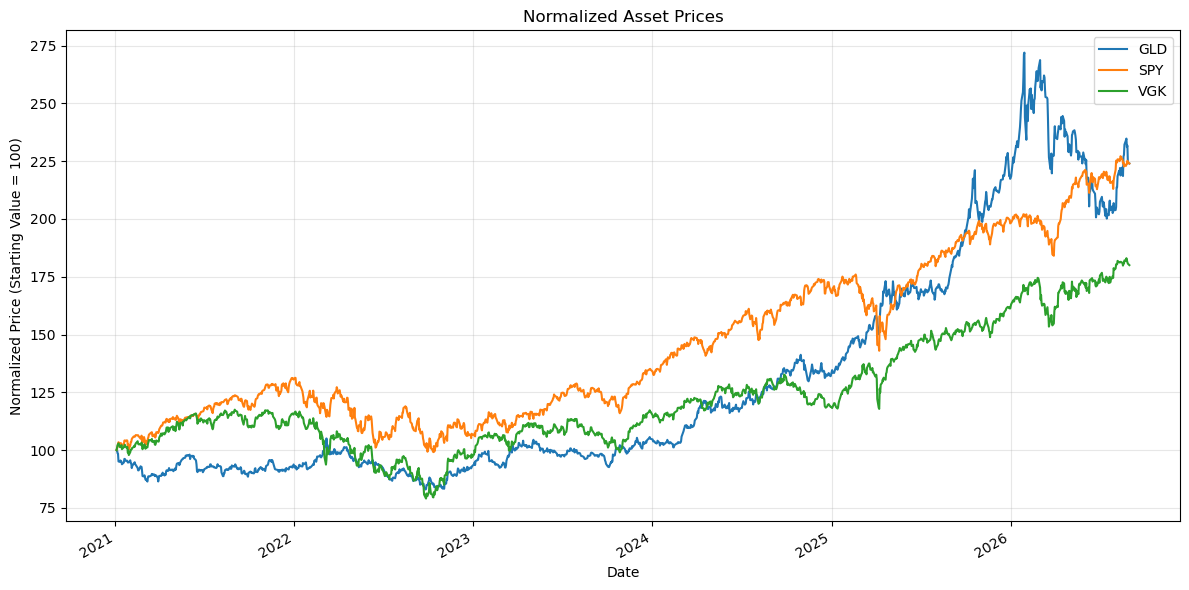

In [9]:
normalized_prices = prices / prices.iloc[0] * 100

ax = normalized_prices.plot(figsize=(12, 6),linewidth=1.5,title="Normalized Asset Prices")

ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price (Starting Value = 100)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/normalized_prices.png", dpi=300)
plt.show()

### Daily Logarithmic Returns

Daily logarithmic returns measure the continuously compounded percentage change in an asset’s price from one trading day to the next.

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

where:

- $r_t$ is the logarithmic return on day $t$;
- $P_t$ is the asset’s price on day $t$;
- $P_{t-1}$ is the asset’s price on the previous trading day;
- $\ln$ represents the natural logarithm.

Returns are used instead of raw prices because they make assets with different price levels easier to compare. They are also useful for calculating volatility, correlations, portfolio performance, and risk measures such as Value at Risk and Expected Shortfall.

In [10]:
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.head()

# price.shift is moving yesterday prices down by one row
# prices/prices.shifts is calculating today prices relative to yesterday price
# .dropna() removes the first row becasue the first date has no previous price



,GLD,SPY,VGK
Date,,,
2021-01-05,0.002957,0.006864,0.008973
2021-01-06,-0.016374,0.005961,0.011787
2021-01-07,-0.002337,0.014748,0.003045
2021-01-08,-0.034809,0.005682,0.004630
2021-01-11,-0.001963,-0.006764,-0.015895


In [11]:
print('Return dataset dimensions:',log_returns.shape)
print('\nMissing values:')
print(log_returns.isna().sum())
log_returns.describe().T

# log_returns.shape returns two numbers
#/n inserts a blank line before heading, making output easier to read
#log_returns.isna checks every value in the dataset if it is missing true or avalibale false and then counts thetrue values in each asset
#It means how large my dataset is and if there are any missing values in the dataset. It is important to check for missing values because they can affect the accuracy of the analysis and may need to be handled before proceeding with further analysis.It also shows what are the main statistics of the log returns dataset. It is important to check the summary statistics to understand the distribution of the data and identify any potential outliers or anomalies.

Return dataset dimensions: (1420, 3)

Missing values:
GLD    0
SPY    0
VGK    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
GLD,1420.0,0.000568,0.011547,-0.108412,-0.005073,0.000623,0.006705,0.061647
SPY,1420.0,0.000568,0.010517,-0.060327,-0.004418,0.000732,0.006283,0.099863
VGK,1420.0,0.000414,0.011025,-0.068214,-0.005776,0.000756,0.006732,0.071805


In [12]:
log_returns.to_csv('../data/log_returns.csv')
print('log returns saved successfully')

log returns saved successfully


### Equally Weighted Portfolio

The portfolio allocates an equal proportion of its capital to each of the three assets. Therefore, each asset receives a weight of one-third.

In [13]:
weights = pd.Series(1/len(log_returns.columns),index=log_returns.columns)
print('Portfolio weights:')
print(weights)
print('Total weight:',weights.sum())

Portfolio weights:
GLD    0.333333
SPY    0.333333
VGK    0.333333
dtype: float64
Total weight: 1.0


In [14]:
portfolio_returns=log_returns.mul(weights).sum(axis=1) #it multiply each assets daily return by it portfolio weight and then sum the weighted returns across all assets for each day to get the daily portfolio return

print('Portfolio return observations:',portfolio_returns.shape[0])
portfolio_returns.head()

Portfolio return observations: 1420


Date
2021-01-05    0.006265
2021-01-06    0.000458
2021-01-07    0.005152
2021-01-08   -0.008166
2021-01-11   -0.008207
dtype: float64

In [15]:
print(portfolio_returns.describe())
print('\nMissing values:',portfolio_returns.isna().sum())

count    1420.000000
mean        0.000517
std         0.008532
min        -0.050737
25%        -0.004115
50%         0.000707
75%         0.005239
max         0.069331
dtype: float64

Missing values: 0


### Portfolio Performance and Volatility

The portfolio's average daily logarithmic return is annualized using 252 trading days. Volatility is annualized using the square-root-of-time rule.

In [16]:
trading_days=252 #This sets the number of trading days in a year to 252, which is a commonly used assumption in finance
annualized_log_returns=portfolio_returns.mean()*trading_days
annualized_volatitility=portfolio_returns.std()*np.sqrt(trading_days)
print(f'Annualized log returns:{annualized_log_returns:.2%}')
print(f'Annualized volatility:{annualized_volatitility :.2%}')

Annualized log returns:13.02%
Annualized volatility:13.54%


In [17]:
cumulative_return=np.exp(portfolio_returns.cumsum()) #This calculates the cumulative returns of the portfolio by taking the exponential of the cumulative sum of the daily portfolio return
print(f'Total cumulative return:{cumulative_return.iloc[-1]:.2%}')


Total cumulative return:208.26%


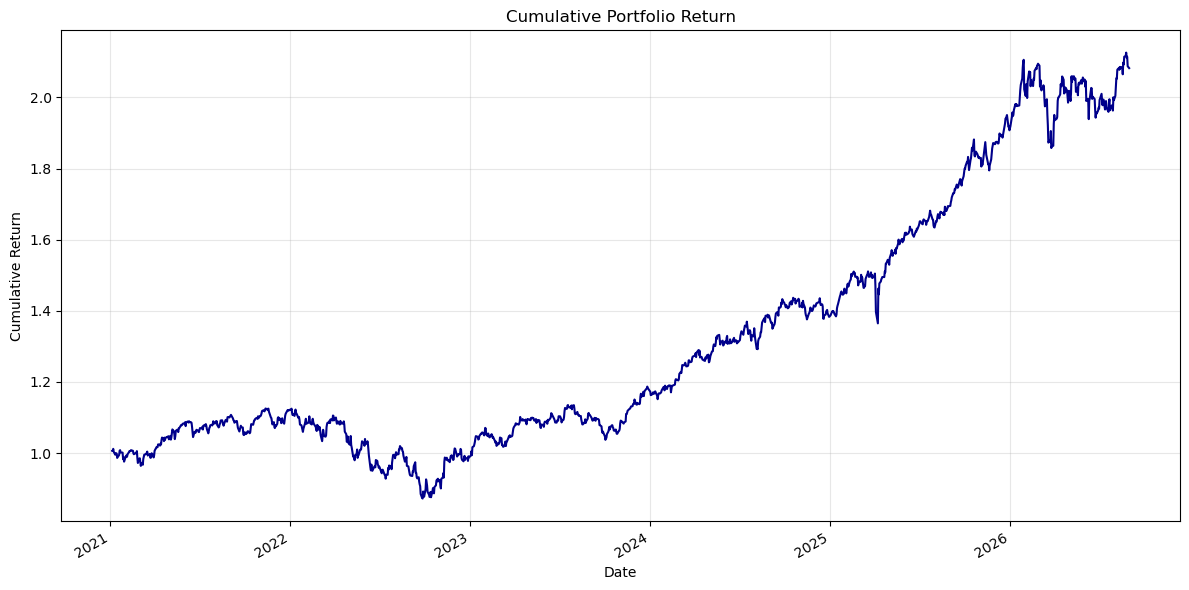

In [18]:
ax = cumulative_return.plot(
    figsize=(12, 6),
    linewidth=1.5,
    color="darkblue",
    title="Cumulative Portfolio Return"
)

ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/cumulative_portfolio_return.png", dpi=300)
plt.show()

## Historical Value at Risk

Historical Value at Risk uses the observed distribution of portfolio returns without assuming a specific theoretical distribution.

A 95% one-day VaR represents the loss threshold that was exceeded on approximately 5% of historical trading days.

In [19]:
confidence_level=0.95
tail_probability = 1 - confidence_level
var_threshold = portfolio_returns.quantile(tail_probability)
historical_var_95 = -var_threshold
print(f'Return threshold:{var_threshold:.4%}')
print(f'95% Historical VaR:{historical_var_95:.4%}')

Return threshold:-1.2973%
95% Historical VaR:1.2973%


In [20]:
#Intrepretation
#Based on the historical sample, the portfolio is expected
#to lose more than approximately 1.30% on 5% of trading days.


In [21]:
exceptions = portfolio_returns < var_threshold
print('Number of observations:',len(portfolio_returns))
print('Number of VaR exceptions:',exceptions.sum())
print(f'Observed exception rate:{exceptions.mean():.2%}')
print(f'expected exception rate:{tail_probability:.2%}')


Number of observations: 1420
Number of VaR exceptions: 71
Observed exception rate:5.00%
expected exception rate:5.00%


## Historical Expected Shortfall

Expected Shortfall estimates the average portfolio loss on days when the loss exceeds the VaR threshold. Unlike VaR, it provides information about the severity of losses in the tail of the distribution.

In [22]:
tail_returns = portfolio_returns[portfolio_returns<=var_threshold]
historical_es_95 = -tail_returns.mean()
print(f'95% Historical ES:{historical_es_95:.4%}')
print(f'95% Historical Expected shortfall:{historical_es_95:.4%}')
print('Number of tail observations:',len(tail_returns))

95% Historical ES:1.9318%
95% Historical Expected shortfall:1.9318%
Number of tail observations: 71


In [23]:
print("Is Expected Shortfall greater than VaR?",historical_es_95 > historical_var_95)

Is Expected Shortfall greater than VaR? True


In [24]:
#VaR tells us where the extreme loss region begins.Expected Shortfall tells us how severe losses within that region were on average.

## Parametric Value at Risk

Parametric VaR estimates risk using the portfolio's mean and standard deviation. The normal parametric method assumes that portfolio returns follow a normal distribution.

In [25]:
from scipy.stats import norm
portfolio_mean = portfolio_returns.mean()
portfolio_volatility = portfolio_returns.std()
z_score = norm.ppf(1 - confidence_level)
parametric_var_95=-(portfolio_mean + z_score * portfolio_volatility)
print(f'Daily mean return:{portfolio_mean:.4%}')
print(f'Daily volatility:{portfolio_volatility:.4%}')
print(f'95% Parametric VaR:{parametric_var_95:.4%}')
print(f"5% normal-distribution z-score: {z_score:.4f}")


Daily mean return:0.0517%
Daily volatility:0.8532%
95% Parametric VaR:1.3517%
5% normal-distribution z-score: -1.6449


In [26]:
print(f"Historical VaR: {historical_var_95:.4%}")
print(f"Parametric VaR: {parametric_var_95:.4%}")

difference = parametric_var_95 - historical_var_95
print(f"Difference: {difference:.4%}")

Historical VaR: 1.2973%
Parametric VaR: 1.3517%
Difference: 0.0544%


### Interpretation

At the 95% confidence level, the Normal Parametric VaR is 1.3517%, while the Historical VaR is 1.2973%. Therefore, the parametric model produces a slightly higher estimated one-day loss threshold.

The difference is 0.0544 percentage points, equivalent to approximately 5.44 basis points. This indicates that the normal-distribution model is slightly more conservative than the historical method at the 95% confidence level for this dataset.

However, this result does not prove that the normal model always estimates greater risk. The comparison may change at higher confidence levels, such as 99%, where extreme observations and heavy tails become more influential.

In [27]:
confidence_level_99 = 0.99
tail_probability_99 = 1 - confidence_level_99
var_threshold_99 = portfolio_returns.quantile(tail_probability_99)
historical_var_99 = -var_threshold_99

print(f"99% Historical VaR: {historical_var_99:.4%}")
z_score_99 = norm.ppf(tail_probability_99)

parametric_var_99 = -(portfolio_mean + z_score_99 * portfolio_volatility)

print(f"99% Parametric VaR: {parametric_var_99:.4%}")
print(f"95% Historical VaR: {historical_var_95:.4%}")
print(f"95% Parametric VaR:  {parametric_var_95:.4%}")
print(f"99% Historical VaR: {historical_var_99:.4%}")
print(f"99% Parametric VaR:  {parametric_var_99:.4%}")

99% Historical VaR: 2.3900%
99% Parametric VaR: 1.9331%
95% Historical VaR: 1.2973%
95% Parametric VaR:  1.3517%
99% Historical VaR: 2.3900%
99% Parametric VaR:  1.9331%


### Comparison Across Confidence Levels

At the 95% confidence level, Parametric VaR is slightly higher than Historical VaR. However, at the 99% confidence level, Historical VaR increases to 2.3900%, compared with a Parametric VaR of 1.9331%.

The Historical VaR estimate is therefore 0.4569 percentage points higher at the 99% confidence level. This suggests that the observed portfolio-return distribution contains more extreme negative returns than the normal model predicts.

The result is consistent with heavy-tailed financial returns and indicates that the normal parametric model may underestimate risk in the extreme lower tail. However, the 99% historical estimate is based on relatively few tail observations, so it may also be sensitive to the sample period.

## Parametric Expected Shortfall

Parametric Expected Shortfall estimates the average loss beyond the Parametric VaR threshold. This method assumes that portfolio returns follow a normal distribution.

In [28]:
def normal_expected_shortfall(returns,confidence_level):
    mean_return = returns.mean()
    volatility = returns.std()
    tail_probability = 1 - confidence_level
    z_score = norm.ppf(tail_probability)
    expected_tail_return = (mean_return - volatility * norm.pdf(z_score)/tail_probability)
    return -expected_tail_return

In [29]:
# this function calculates the mean and volatility
#finds lower tail z score
#estimates the average return inside that tail and changes the negative return into a positive loss measure

In [30]:
parametric_es_95 = normal_expected_shortfall(portfolio_returns,0.95)

parametric_es_99 = normal_expected_shortfall(portfolio_returns,0.99)

print(f"95% Parametric Expected Shortfall: {parametric_es_95:.4%}")
print(f"99% Parametric Expected Shortfall: {parametric_es_99:.4%}")

95% Parametric Expected Shortfall: 1.7082%
99% Parametric Expected Shortfall: 2.2223%


In [31]:
tail_returns_99 = portfolio_returns[portfolio_returns <= var_threshold_99]

historical_es_99 = -tail_returns_99.mean()

print(f"95% Historical Expected Shortfall: {historical_es_95:.4%}")
print(f"99% Historical Expected Shortfall: {historical_es_99:.4%}")

95% Historical Expected Shortfall: 1.9318%
99% Historical Expected Shortfall: 2.9116%


In [32]:
print("95% Parametric ES greater than Parametric VaR:",parametric_es_95 > parametric_var_95)

print("99% Parametric ES greater than Parametric VaR:",parametric_es_99 > parametric_var_99)

95% Parametric ES greater than Parametric VaR: True
99% Parametric ES greater than Parametric VaR: True


In [33]:
#Parametric ES is greater as it measures the average of losses beyond the VaR threshold

## Risk Measure Comparison

The following table compares Historical and Normal Parametric VaR and Expected Shortfall at the 95% and 99% confidence levels.

In [34]:
risk_comparison = pd.DataFrame({"Confidence Level": ["95%", "95%", "99%", "99%"],"Method": ["Historical","Parametric Normal","Historical","Parametric Normal"],"VaR": [
        historical_var_95,
        parametric_var_95,
        historical_var_99,
        parametric_var_99
    ],
    "Expected Shortfall": [
        historical_es_95,
        parametric_es_95,
        historical_es_99,
        parametric_es_99
    ]
})

risk_comparison

,Confidence Level,Method,VaR,Expected Shortfall
0,95%,Historical,0.012973,0.019318
1,95%,Parametric Normal,0.013517,0.017082
2,99%,Historical,0.023900,0.029116
3,99%,Parametric Normal,0.019331,0.022223


In [35]:
formatted_comparison = risk_comparison.copy()

formatted_comparison["VaR"] = (
    formatted_comparison["VaR"].map("{:.4%}".format)
)

formatted_comparison["Expected Shortfall"] = (
    formatted_comparison["Expected Shortfall"].map("{:.4%}".format)
)

formatted_comparison

,Confidence Level,Method,VaR,Expected Shortfall
0,95%,Historical,1.2973%,1.9318%
1,95%,Parametric Normal,1.3517%,1.7082%
2,99%,Historical,2.3900%,2.9116%
3,99%,Parametric Normal,1.9331%,2.2223%


In [36]:
risk_comparison.to_csv("../data/risk_measure_comparison.csv",index=False)

print("Risk comparison table saved successfully.")

Risk comparison table saved successfully.


### Interpretation of Risk Estimates

Expected Shortfall exceeds VaR for every method and confidence level. This is expected because VaR identifies the threshold at which extreme losses begin, whereas Expected Shortfall measures the average loss beyond that threshold.

Both VaR and Expected Shortfall increase when the confidence level rises from 95% to 99%. A higher confidence level focuses on rarer and more severe losses, resulting in larger risk estimates.

At the 95% confidence level, Parametric VaR is slightly higher than Historical VaR. However, Historical Expected Shortfall is higher, indicating that the observed losses beyond the historical VaR threshold are more severe than those implied by the normal model.

At the 99% confidence level, both Historical VaR and Historical Expected Shortfall are substantially higher than the corresponding parametric estimates. This suggests that the historical return distribution contains more extreme negative observations than predicted by the normal distribution. The result is consistent with heavy-tailed financial returns and indicates that the normal model may underestimate extreme tail risk.

### Visual Comparison of VaR and Expected Shortfall

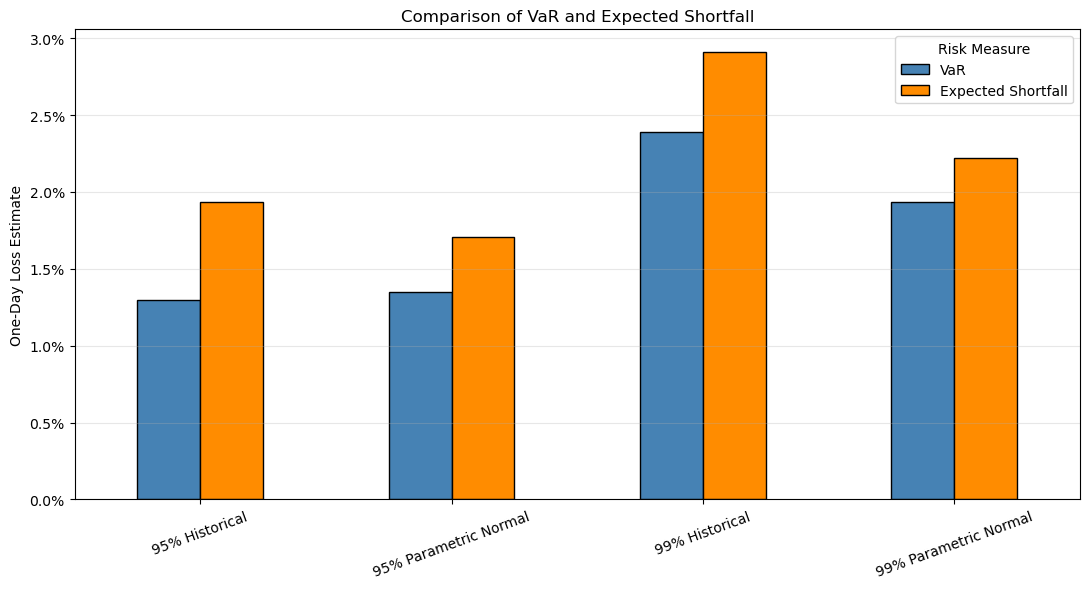

In [37]:
plot_data = risk_comparison.copy()

plot_data["Model"] = (
    plot_data["Confidence Level"]
    + " "
    + plot_data["Method"]
)

plot_data = plot_data.set_index("Model")

ax = plot_data[["VaR", "Expected Shortfall"]].plot(
    kind="bar",
    figsize=(11, 6),
    color=["steelblue", "darkorange"],
    edgecolor="black"
)

ax.set_title("Comparison of VaR and Expected Shortfall")
ax.set_xlabel("")
ax.set_ylabel("One-Day Loss Estimate")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, position: f"{value:.1%}")
)
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)

plt.legend(title="Risk Measure")
plt.tight_layout()
plt.savefig(
    "../figures/var_es_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Dependence Analysis

Correlation measures the strength and direction of the relationship between asset returns. Covariance measures how asset returns move together and preserves information about their volatility.

Understanding dependence is important because diversification benefits depend on assets not moving perfectly together.

In [38]:
correlation_matrix = log_returns.corr()
daily_covariance_matrix = log_returns.cov()
annualized_covariance_matrix = daily_covariance_matrix * 252

print("Correlation matrix:")
display(correlation_matrix)

print("Annualized covariance matrix:")
display(annualized_covariance_matrix)

Correlation matrix:


,GLD,SPY,VGK
GLD,1.000000,0.155006,0.296890
SPY,0.155006,1.000000,0.760565
VGK,0.296890,0.760565,1.000000


Annualized covariance matrix:


,GLD,SPY,VGK
GLD,0.033602,0.004744,0.009525
SPY,0.004744,0.027875,0.022224
VGK,0.009525,0.022224,0.030631


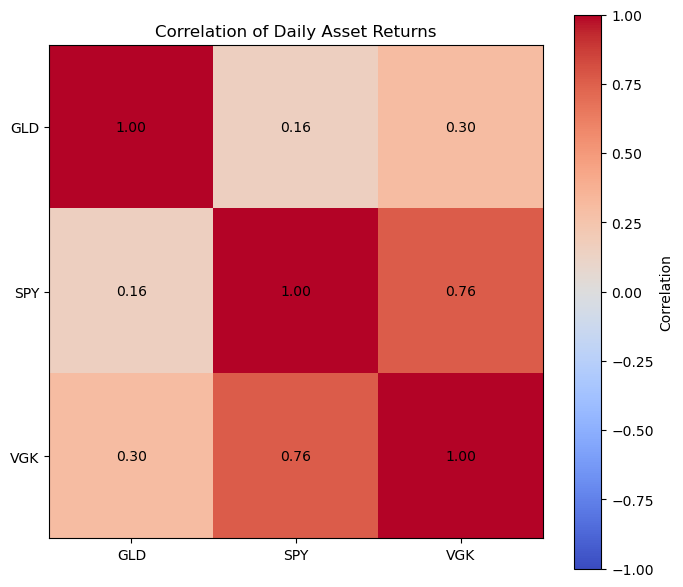

In [39]:
fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.index)))

ax.set_xticklabels(correlation_matrix.columns)
ax.set_yticklabels(correlation_matrix.index)

for row in range(len(correlation_matrix.index)):
    for column in range(len(correlation_matrix.columns)):
        value = correlation_matrix.iloc[row, column]

        ax.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="black"
        )

fig.colorbar(image, ax=ax, label="Correlation")
ax.set_title("Correlation of Daily Asset Returns")

plt.tight_layout()
plt.savefig(
    "../figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Interpretation of Asset Correlations

SPY and VGK have the highest correlation, at 0.76, indicating that US and European equity returns frequently move in the same direction.

GLD and SPY have the lowest correlation, at 0.16, while the correlation between GLD and VGK is 0.30. Gold therefore has a weaker linear relationship with both equity markets and contributes diversification benefits to the portfolio.

However, correlation is not constant over time. Dependence between assets may change, particularly during periods of financial stress. Therefore, the full-sample correlation matrix may not completely represent the portfolio's behaviour during extreme market conditions.

## Portfolio Return Distribution

This section examines whether portfolio returns follow a normal distribution. Skewness measures asymmetry, while excess kurtosis measures whether the distribution has heavier or lighter tails than a normal distribution.

In [40]:
from scipy.stats import skew, kurtosis
portfolio_skewness = skew(portfolio_returns)
portfolio_excess_kurtosis = kurtosis(portfolio_returns,fisher=True)
print(f'skewness:{portfolio_skewness:.4f}')
print(f'excess kurtosis:{portfolio_excess_kurtosis:.4f}')

skewness:0.0357
excess kurtosis:5.2788


### Skewness and Kurtosis Interpretation

The portfolio-return distribution has a skewness of 0.0357, which is close to zero. This indicates that the distribution is approximately symmetric, with only a slight positive skew.

The excess kurtosis is 5.2788, considerably above the normal-distribution benchmark of zero. This provides evidence that the portfolio returns are leptokurtic, meaning the distribution has a sharper central peak and heavier tails than a normal distribution.

Consequently, extreme returns occur more frequently than the normal model predicts. This result helps explain why the 99% Historical VaR is higher than the 99% Normal Parametric VaR. Although the overall distribution is approximately symmetric, heavy tails remain an important source of risk.

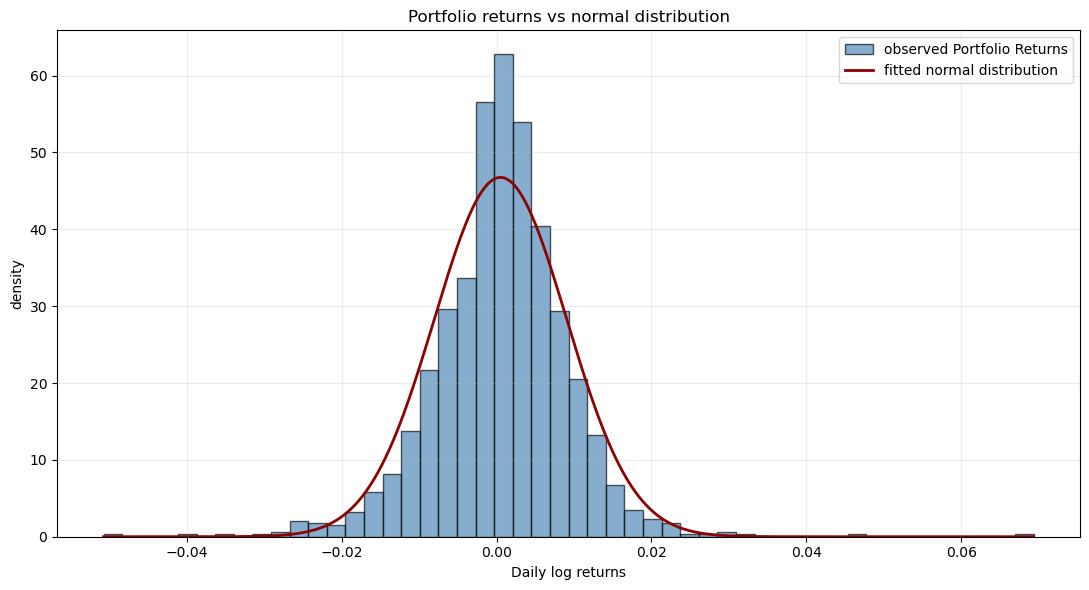

In [41]:
mean_return = portfolio_returns.mean()
standard_deviation = portfolio_returns.std()
x_values = np.linspace(portfolio_returns.min(),portfolio_returns.max(),500)
normal_density = norm.pdf(x_values,loc=mean_return,scale=standard_deviation)
fig, ax= plt.subplots(figsize=(11,6))
ax.hist(portfolio_returns,bins=50,density=True,alpha=0.65,color='steelblue',edgecolor='black',label='observed Portfolio Returns')
ax.plot(x_values,normal_density,color='darkred',linewidth=2,label='fitted normal distribution')
ax.set_title('Portfolio returns vs normal distribution')
ax.set_xlabel('Daily log returns')
ax.set_ylabel('density')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig('../figures/portfolio_returns_vs_normal_distribution.png',dpi=300,bbox_inches='tight')
plt.show()

### Distribution Comparison

The observed portfolio-return distribution has a noticeably sharper peak around zero than the fitted normal distribution. This indicates that small daily returns occur more frequently than predicted by the normal model.

The histogram also contains observations far into both the negative and positive tails, while the fitted normal density assigns very little probability to such extreme outcomes. This visually supports the excess kurtosis estimate of 5.2788 and provides evidence that the portfolio returns have heavy tails.

Although the distribution appears approximately symmetric, its tail behaviour differs substantially from the normal distribution. Consequently, a normal parametric risk model may underestimate the probability and severity of extreme portfolio returns.

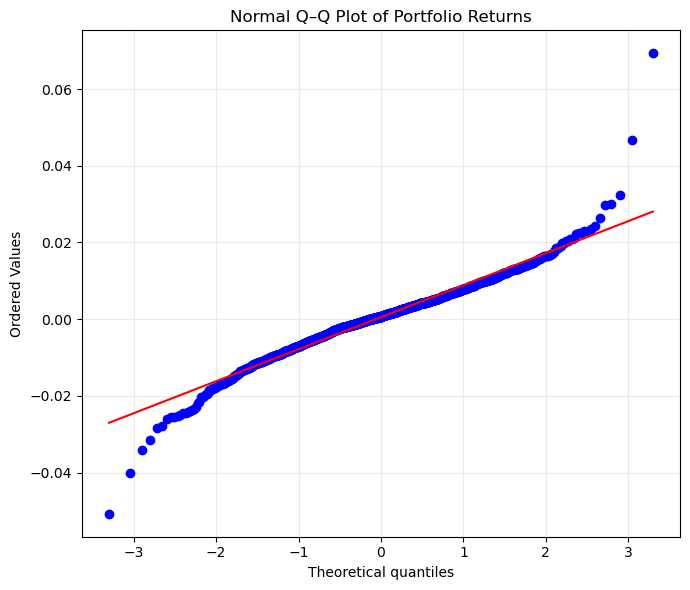

In [42]:
from scipy.stats import probplot

fig, ax = plt.subplots(figsize=(7, 6))

probplot(portfolio_returns,dist="norm",plot=ax)

ax.set_title("Normal Q–Q Plot of Portfolio Returns")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("../figures/portfolio_returns_qq_plot.png",dpi=300,bbox_inches="tight")
plt.show()

### Q–Q Plot Interpretation

Most observations near the centre of the Q–Q plot follow the normal reference line reasonably closely. This suggests that the normal distribution provides an approximate representation of ordinary portfolio returns.

However, the observations deviate substantially from the reference line in both tails. The lower-tail observations fall below the line, indicating more severe negative returns than predicted by the normal model. The upper-tail observations rise above the line, indicating more extreme positive returns.

These deviations provide visual evidence of heavy-tailed portfolio returns and are consistent with the excess kurtosis estimate of 5.2788. Therefore, the normal model may provide a reasonable approximation near the centre of the distribution but does not adequately represent extreme outcomes.

## Rolling Historical VaR Backtesting

A rolling Historical VaR model uses a moving window of previous portfolio returns to estimate the risk for the next trading day.

This analysis uses the previous 250 trading days, representing approximately one trading year, to forecast the 95% one-day VaR. The current day's return is excluded from its own VaR estimate to prevent look-ahead bias.

In [43]:
rolling_window = 250
backtest_confidence_level = 0.95
backtest_tail_probability = 1 - backtest_confidence_level

rolling_historical_var_95 = -(portfolio_returns.rolling(window=rolling_window).quantile(backtest_tail_probability).shift(1))




rolling_historical_var_95.dropna().head()

Date
2021-12-31    0.011212
2022-01-03    0.011212
2022-01-04    0.011212
2022-01-05    0.011212
2022-01-06    0.011212
dtype: float64

Based on the preceding 250 trading days, the model estimated a 95% one-day portfolio loss threshold of approximately 1.12%.

In [44]:
backtest_results = pd.DataFrame({
    "Portfolio Return": portfolio_returns,
    "Portfolio Loss": -portfolio_returns,
    "Historical VaR 95%": rolling_historical_var_95
}).dropna()

backtest_results["Exception"] = (
    backtest_results["Portfolio Loss"]
    > backtest_results["Historical VaR 95%"]
)

backtest_results.head()

,Portfolio Return,Portfolio Loss,Historical VaR 95%,Exception
Date,,,,
2021-12-31,0.001428,-0.001428,0.011212,False
2022-01-03,-0.000083,0.000083,0.011212,False
2022-01-04,0.002770,-0.002770,0.011212,False
2022-01-05,-0.010477,0.010477,0.011212,False
2022-01-06,-0.005641,0.005641,0.011212,False


In [45]:
number_of_forecasts = len(backtest_results)
number_of_exceptions = backtest_results["Exception"].sum()
observed_exception_rate = backtest_results["Exception"].mean()

print("Number of VaR forecasts:", number_of_forecasts)
print("Number of exceptions:", number_of_exceptions)
print(f"Observed exception rate: {observed_exception_rate:.2%}")
print("Expected exception rate: 5.00%")

Number of VaR forecasts: 1170
Number of exceptions: 77
Observed exception rate: 6.58%
Expected exception rate: 5.00%


### Preliminary Backtesting Results

The rolling 95% Historical VaR model generated 1,170 one-day forecasts and 77 exceptions. The observed exception rate was 6.58%, compared with the theoretically expected rate of 5.00%.

At the 5% expected exception rate, approximately 58.5 exceptions would have been anticipated. The model therefore produced around 18.5 more exceptions than expected.

This preliminary result suggests that the model may underestimate portfolio risk. However, a formal statistical test is required to determine whether the difference between the observed and expected exception rates is statistically significant.

In [46]:
import matplotlib.pyplot as plt

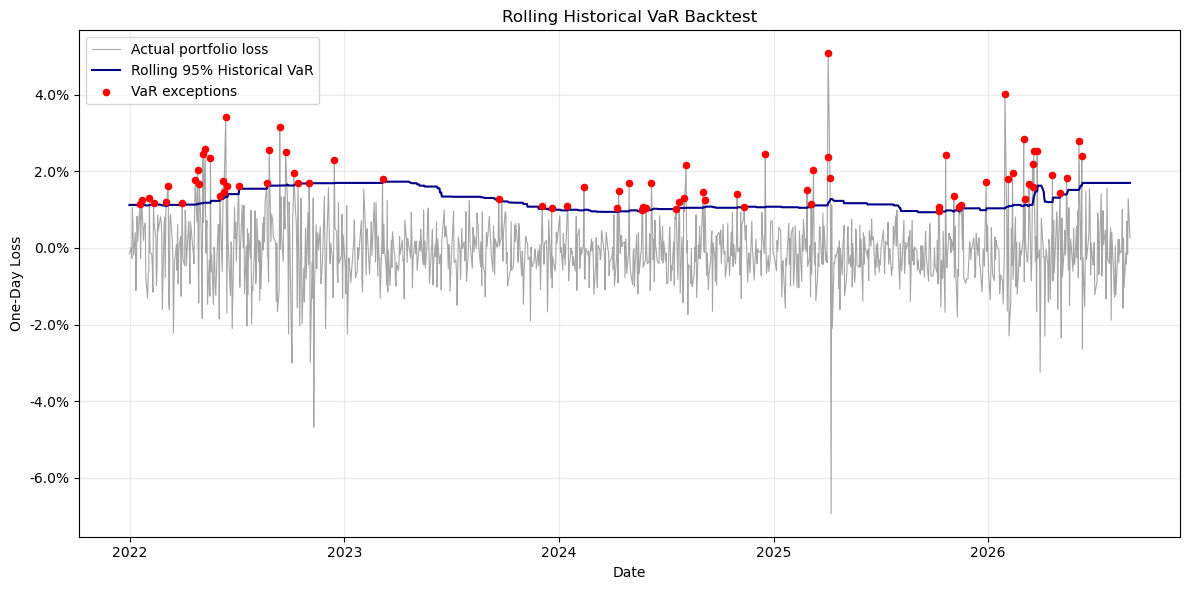

In [47]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(backtest_results.index,backtest_results["Portfolio Loss"],color="gray",linewidth=0.8,alpha=0.7,label="Actual portfolio loss")

ax.plot(backtest_results.index,backtest_results["Historical VaR 95%"],color="darkblue",linewidth=1.5,label="Rolling 95% Historical VaR")

exception_days = backtest_results[backtest_results["Exception"]]

ax.scatter(exception_days.index,exception_days["Portfolio Loss"],color="red",s=20,label="VaR exceptions",zorder=3)

ax.set_title("Rolling Historical VaR Backtest")
ax.set_xlabel("Date")
ax.set_ylabel("One-Day Loss")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, position: f"{value:.1%}"))
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.savefig("../figures/historical_var_backtest.png",dpi=300,bbox_inches="tight")
plt.show()

In [48]:
from scipy.stats import chi2
import numpy as np
n = len (backtest_results)
x = int(backtest_results['Exception'].sum())
expected_rate = 0.05
observed_rate = x / n
log_expected = ((n-x)*np.log(1-expected_rate)+x*np.log(expected_rate))
log_observed=((n-x)*np.log(1-observed_rate)+x*np.log(observed_rate))
kupiec_statistic=-2*(log_expected-log_observed)
p_value=chi2.sf(kupiec_statistic,df=1) 
print(f'kupiec statistic:{kupiec_statistic:.4f}')
print(f'p-value:{p_value:.4f}')

kupiec statistic:5.6256
p-value:0.0177


### Kupiec Backtest Result

The rolling 95% Historical VaR model produced 77 exceptions across 1,170 forecasts, an observed exception rate of 6.58% versus the expected 5%.

The Kupiec unconditional-coverage statistic is 5.6256, with a p-value of 0.0177. At the 5% significance level, the expected exception rate is rejected. Because exceptions occurred more frequently than expected, the model appears to underestimate risk over this backtest period.

This test evaluates the overall exception frequency, not whether exceptions are independent or clustered over time.

### Exceptions by Year

This analysis checks whether VaR exceptions were spread evenly over time or concentrated in particular years.

In [49]:
exceptions_by_year = backtest_results.groupby(backtest_results.index.year).agg(Forecasts=('Exception','size'),Exceptions=('Exception','sum'))
exceptions_by_year['Exception Rate']=(exceptions_by_year['Exceptions']/ exceptions_by_year['Forecasts'])
display(exceptions_by_year.style.format({'Exception Rate':'{:.2%}'}))

,Forecasts,Exceptions,Exception Rate
Date,,,
2021,1,0,0.00%
2022,251,27,10.76%
2023,250,4,1.60%
2024,252,18,7.14%
2025,250,13,5.20%
2026,166,15,9.04%


### Exceptions Over Time

The highest exception rate occurred in 2022: 27 exceptions across 251 forecasts, or 10.76%, compared with the 5% rate expected from a 95% VaR model.

Exception rates varied substantially across years, falling to 1.60% in 2023 and rising again in 2024 and the partial 2026 sample. This suggests that the model's accuracy changed with market conditions. Annual totals do not, however, establish whether exceptions occurred in consecutive-day clusters.

In [50]:
worst_days=backtest_results.nlargest(10,'Portfolio Loss')[['Portfolio Loss','Historical VaR 95%', 'Exception']]
display(worst_days.style.format({'Portfolio Loss':'{:.2%}','Historical VaR 95%':'{:.2%}'}))

,Portfolio Loss,Historical VaR 95%,Exception
Date,,,
2025-04-04 00:00:00,5.07%,1.17%,True
2026-01-30 00:00:00,4.02%,1.03%,True
2022-06-13 00:00:00,3.40%,1.33%,True
2022-09-13 00:00:00,3.14%,1.62%,True
2026-03-03 00:00:00,2.84%,1.09%,True
2026-06-05 00:00:00,2.78%,1.51%,True
2022-05-09 00:00:00,2.59%,1.18%,True
2022-08-26 00:00:00,2.56%,1.62%,True
2026-03-20 00:00:00,2.54%,1.31%,True


### Worst-Day Analysis

The largest observed daily portfolio loss was 5.07% on 4 April 2025, compared with a preceding 95% Historical VaR forecast of 1.17%. The loss exceeded the forecast threshold by approximately 3.90 percentage points.

All ten worst loss days were VaR exceptions. This is not surprising because VaR specifies a threshold, not a maximum possible loss. These observations show why Expected Shortfall and stress analysis are useful alongside VaR: they help examine how severe losses can be after the threshold is crossed.

## Estimation-Window Sensitivity

Historical VaR depends on how much past data is used. A shorter window may adapt more quickly to changing markets, while a longer window uses more observations but may react more slowly.

In [51]:
windows = [125, 250, 500]

window_comparison = pd.DataFrame({
    "Portfolio Loss": -portfolio_returns
})

for window in windows:
    window_comparison[f"VaR {window} days"] = -(
        portfolio_returns
        .rolling(window=window)
        .quantile(0.05)
        .shift(1)
    )

# Keep only dates where all three forecasts exist.
window_comparison = window_comparison.dropna()

results = []

for window in windows:
    exceptions = (
        window_comparison["Portfolio Loss"]
        > window_comparison[f"VaR {window} days"]
    )

    results.append({
        "Window": window,
        "Forecasts": len(exceptions),
        "Exceptions": int(exceptions.sum()),
        "Exception Rate": exceptions.mean()
    })

sensitivity_results = pd.DataFrame(results).set_index("Window")

display(
    sensitivity_results.style.format({
        "Exception Rate": "{:.2%}"
    })
)


,Forecasts,Exceptions,Exception Rate
Window,,,
125,920,46,5.00%
250,920,50,5.43%
500,920,45,4.89%


### Estimation-Window Sensitivity

Using a common evaluation period of 920 trading days, the 125-day, 250-day and 500-day Historical VaR models produced exception rates of 5.00%, 5.43% and 4.89%, respectively. All three rates are close to the 5% target.

The 250-day rate differs from the earlier full backtest rate of 6.58% because the common-period comparison excludes earlier forecast dates. This shows that model evaluation is sensitive not only to the estimation-window length but also to the selected evaluation period.

The 125-day window matching 5% exactly does not, by itself, establish that it is the best model. Exception timing, loss severity and performance in other periods also matter.

## Final Findings

This project analysed an equally weighted portfolio of SPY, VGK and GLD using daily market data. It compared historical and normal parametric risk estimates and evaluated a rolling 95% Historical VaR model.

At the 95% confidence level, Historical VaR was **1.2973%** and Normal Parametric VaR was **1.3517%**. At the 99% confidence level, the relationship reversed: Historical VaR was **2.3900%**, compared with Normal Parametric VaR of **1.9331%**. Expected Shortfall exceeded VaR in every model, showing that losses beyond the VaR threshold can be substantially more severe.

Portfolio returns had skewness of **0.0357** and excess kurtosis of **5.2788**. The histogram and Q–Q plot showed pronounced deviations from the normal distribution in both tails. These findings are consistent with the normal model understating extreme outcomes in this sample, particularly at the 99% confidence level.

The rolling 95% Historical VaR backtest produced **77 exceptions in 1,170 forecasts**, an exception rate of **6.58%** versus the expected **5%**. The Kupiec test returned a p-value of **0.0177**, rejecting the expected exception rate at the 5% significance level. Exceptions were especially frequent in 2022.

Over a shorter common evaluation period of 920 days, the 125-, 250- and 500-day estimation windows produced exception rates of **5.00%**, **5.43%** and **4.89%**, respectively. This demonstrates that conclusions about model performance depend partly on the evaluation period.

## Limitations

- Historical results may not represent future market conditions.
- Normal Parametric VaR assumes a normal return distribution, while the observed returns have heavy tails.
- Historical VaR responds only as extreme observations enter or leave its estimation window.
- The Kupiec test checks the total exception rate; it does not test whether exceptions cluster over time.
- The portfolio uses fixed equal weights and does not include trading costs, liquidity effects or rebalancing costs.
- The weighted average of asset log returns is an approximation to the exact return of a rebalanced portfolio.
- The results depend on the selected assets, sample dates, confidence levels and estimation windows.
- SPY, VGK and GLD are US-listed ETFs. For a euro-based investor, currency exposure would also matter.

## Conclusion

No single risk measure fully describes potential portfolio losses. VaR identifies a loss threshold, Expected Shortfall describes the average severity beyond that threshold, and backtesting checks how forecasts perform against realised outcomes. Using these methods together provides a more informative assessment than relying on one estimate alone.